In [3]:
import requests
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
url = "https://api.open-meteo.com/v1/forecast"

params = {
    "latitude": 31.1048,
    "longitude": 77.1734,
    "hourly": "temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m",
    "forecast_days": 7
}

response = requests.get(url, params=params)

data = response.json()

In [49]:
df = pd.DataFrame({
    "Temperature": data["hourly"]["temperature_2m"],
    "Humidity": data["hourly"]["relative_humidity_2m"],
    "Pressure": data["hourly"]["surface_pressure"],
    "WindSpeed": data["hourly"]["wind_speed_10m"]
})

df.head()

,Temperature,Humidity,Pressure,WindSpeed
0,16.2,98,780.7,1.9
1,16.7,99,780.8,3.3
2,17.6,94,781.4,1.7
3,19.4,81,782.2,4.8
4,20.8,71,782.8,8.1


In [51]:
df["Weather_Class"] = df["Temperature"].apply(
    lambda x: "Warm" if x >= 20 else "Cool"
)

In [53]:
df.isnull().sum()

Temperature      0
Humidity         0
Pressure         0
WindSpeed        0
Weather_Class    0
dtype: int64

In [55]:
encoder = LabelEncoder()

df["Weather_Class"] = encoder.fit_transform(df["Weather_Class"])

df.head()

,Temperature,Humidity,Pressure,WindSpeed,Weather_Class
0,16.2,98,780.7,1.9,0
1,16.7,99,780.8,3.3,0
2,17.6,94,781.4,1.7,0
3,19.4,81,782.2,4.8,0
4,20.8,71,782.8,8.1,1


In [57]:
X = df[["Temperature",
        "Humidity",
        "Pressure",
        "WindSpeed"]]

y = df["Weather_Class"]

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [61]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [63]:
svm = SVC(kernel="rbf")

svm.fit(X_train, y_train)

SVC()

In [65]:
y_pred = svm.predict(X_test)

In [67]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nClassification Report\n")

print(classification_report(y_test, y_pred))

Accuracy : 0.9705882352941176
Precision: 1.0
Recall   : 0.75
F1 Score : 0.8571428571428571

Classification Report

              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      0.75      0.86         4

    accuracy                           0.97        34
   macro avg       0.98      0.88      0.92        34
weighted avg       0.97      0.97      0.97        34



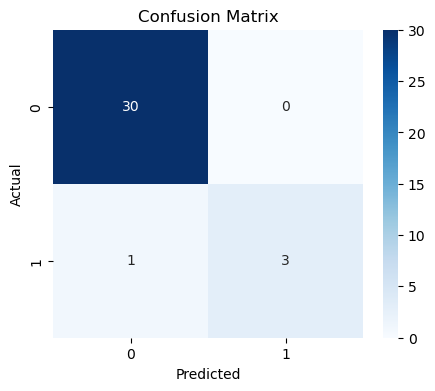

In [69]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            cmap="Blues",
            fmt="d")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [45]:
'''
CO

,Temperature,Humidity,Pressure,WindSpeed,Weather_Class
0,29.7,84,975.1,2.3,0
1,29.9,82,975.2,2.4,0
2,30.5,79,975.7,1.7,0
3,31.4,75,975.7,2.3,0
4,32.4,69,975.6,2.1,0
5,33.2,65,976.0,2.3,0
6,34.3,55,975.4,1.4,0
7,35.1,53,975.5,4.2,0
8,35.2,54,974.8,4.4,0
9,35.3,53,973.8,5.4,0
